In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import MultiComparison

In [10]:
file_path = r"C:\Users\phunk\OneDrive\Desktop\MyProject\Elder BKK\data\Raw Data.xlsx"
df = pd.read_excel(file_path)

In [11]:
df.head()

,REG,CWT,AREA,MEMBERS,SEX,AGE,AGE_GROUP,MARITAL,TOTAL_HR,APPROX,RE_ED
0,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,2,ชาย,53,45-59 ปี,โสด,48,15000,ปริญญาตรี
1,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,1,ชาย,31,30-44 ปี,โสด,48,15000,มัธยมศึกษาตอนต้น
2,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,4,ชาย,60,60 ปีขึ้นไป,ม่าย,48,10400,มัธยมศึกษาตอนต้น
3,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,1,หญิง,45,45-59 ปี,โสด,35,32000,ปริญญาโท
4,กรุงเทพมหานคร,กรุงเทพมหานคร,ในเขตเทศบาล,4,ชาย,37,30-44 ปี,โสด,48,45000,ปริญญาตรี


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20625 entries, 0 to 20624
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   REG        20625 non-null  str  
 1   CWT        20625 non-null  str  
 2   AREA       20625 non-null  str  
 3   MEMBERS    20625 non-null  int64
 4   SEX        20625 non-null  str  
 5   AGE        20625 non-null  int64
 6   AGE_GROUP  20625 non-null  str  
 7   MARITAL    20625 non-null  str  
 8   TOTAL_HR   20625 non-null  int64
 9   APPROX     20625 non-null  int64
 10  RE_ED      20625 non-null  str  
dtypes: int64(4), str(7)
memory usage: 1.7 MB


In [13]:
df.describe()

,MEMBERS,AGE,TOTAL_HR,APPROX
count,20625.000000,20625.000000,20625.000000,20625.000000
mean,2.912048,39.869576,44.809164,21294.017600
std,1.601621,11.783995,10.504683,76261.429519
min,1.000000,15.000000,0.000000,500.000000
25%,2.000000,30.000000,40.000000,9178.000000
50%,3.000000,39.000000,48.000000,12000.000000
75%,4.000000,49.000000,48.000000,18000.000000
max,12.000000,89.000000,98.000000,999999.000000


In [14]:
for col in df.select_dtypes(include=["str"]).columns:
    print(f"{col}: {df[col].nunique()}")

REG: 2
CWT: 26
AREA: 2
SEX: 2
AGE_GROUP: 5
MARITAL: 6
RE_ED: 11


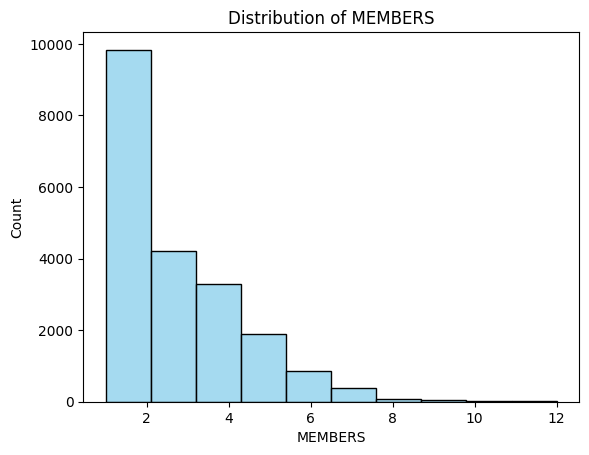

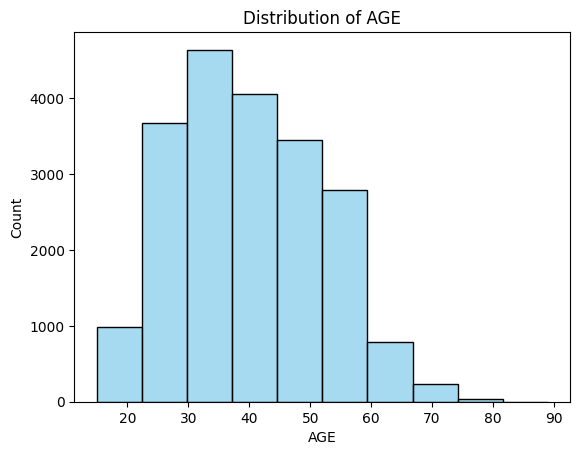

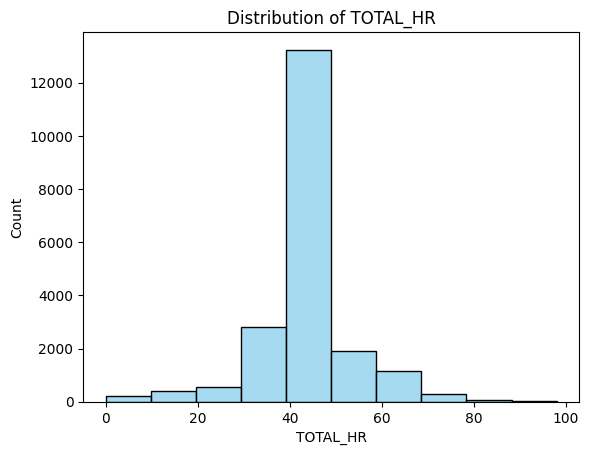

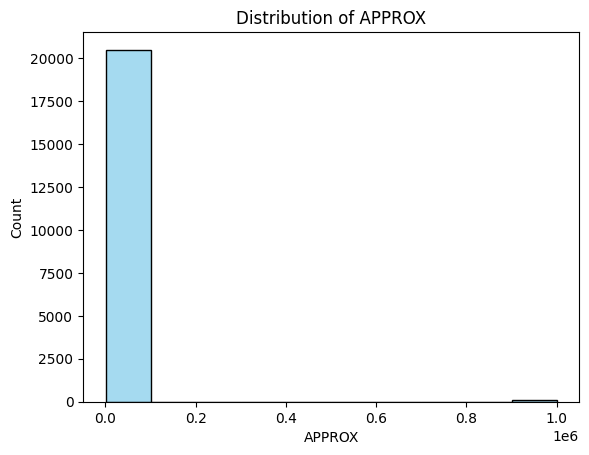

In [15]:
for col in df.select_dtypes(include="number").columns:
    plt.Figure(figsize=(10, 4))
    sns.histplot(df[col], bins=10, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.show()

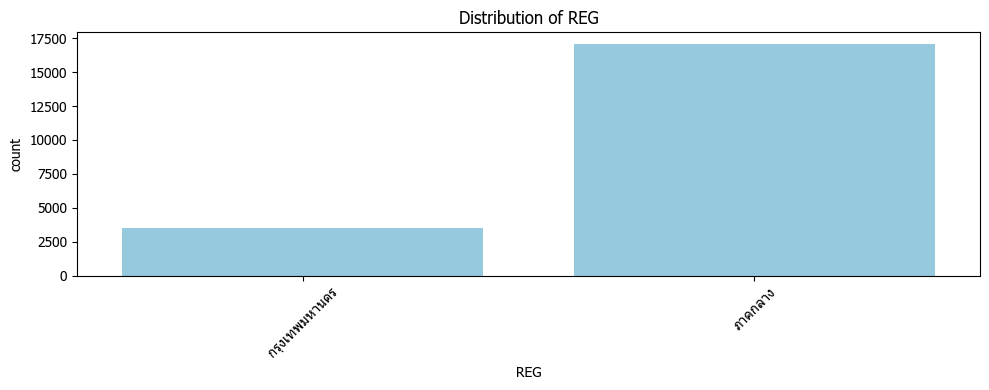

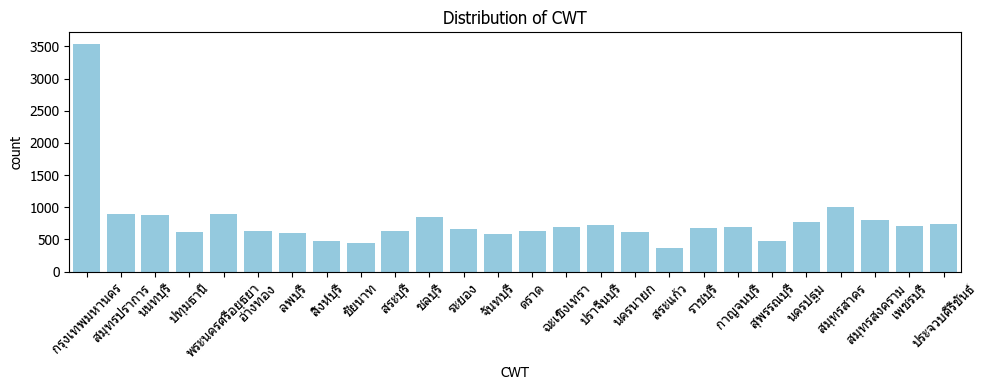

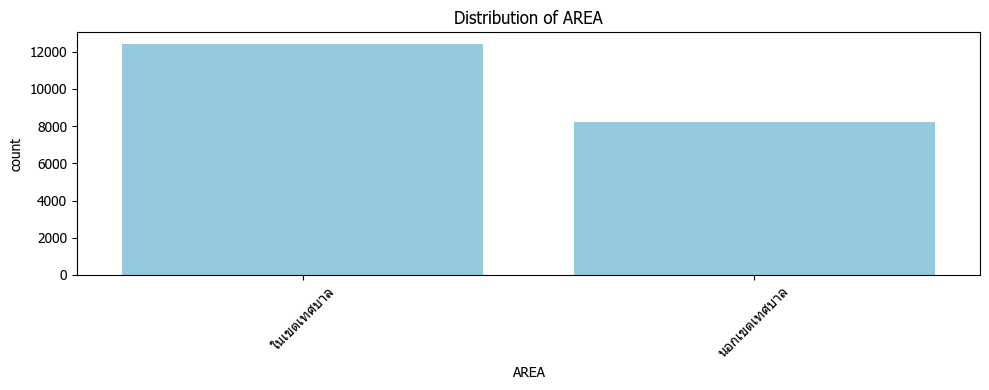

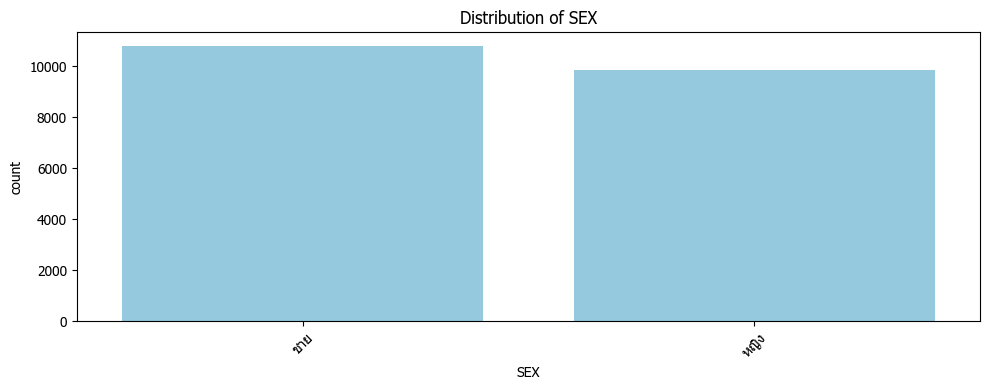

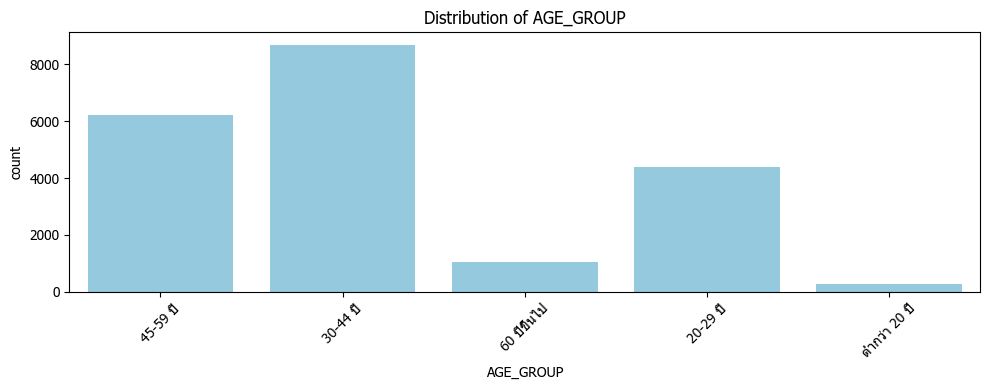

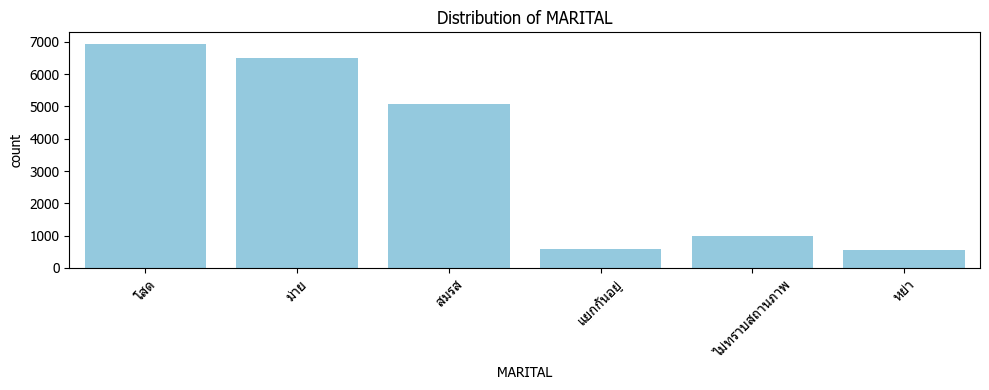

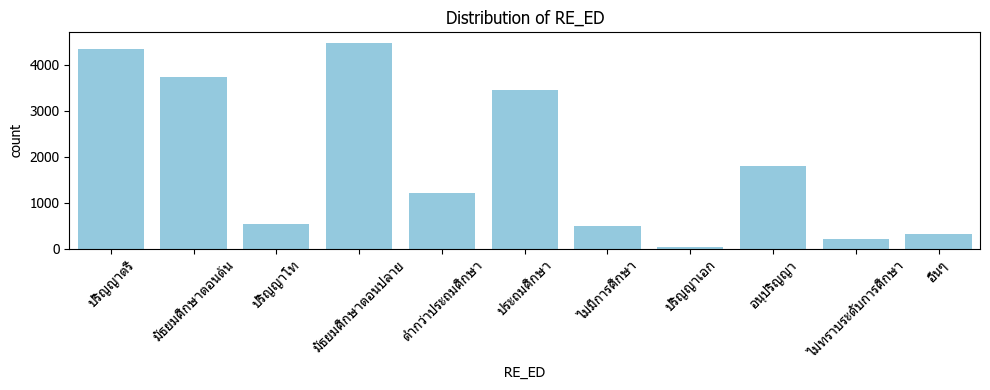

In [35]:
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False

for col in df.select_dtypes(include=["object", "category", "string"]):
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, color="skyblue")
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [36]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ AGE แบ่งตาม CWT")
print("=========================================================")
desc_stats = df.groupby('CWT')['AGE'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('AGE ~ C(CWT)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(CWT)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['AGE'], df['CWT'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('CWT')['AGE'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('CWT')['AGE'].mean().reset_index()
    rank_summary['CWT_STR'] = rank_summary['CWT'].astype(str)
    rank_summary['Group Sign'] = rank_summary['CWT_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='AGE', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['CWT', 'AGE', 'Group Sign']]
    rank_summary.columns = ['CWT Status (CWT)', 'Mean AGE', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ AGE แบ่งตาม CWT
                 count  mean   std  min  median  max
CWT                                                 
สุพรรณบุรี         475 43.43 12.26   19    44.0   79
จันทบุรี           592 42.27 12.89   18    41.5   89
อ่างทอง            636 42.06 12.68   18    42.0   80
สิงห์บุรี          477 42.06 12.32   18    42.0   78
ชัยนาท             452 41.95 12.85   15    42.0   70
สมุทรสงคราม        796 41.88 12.67   16    41.0   75
ลพบุรี             603 41.22 10.76   16    40.0   72
ประจวบคีรีขันธ์    740 40.94 12.34   16    41.0   72
เพชรบุรี           712 40.78 12.41   15    41.0   82
นครนายก            611 40.72 12.24   16    40.0   76
กาญจนบุรี          687 40.45 12.90   15    40.0   81
ปทุมธานี           623 40.22 10.98   16    41.0   70
สระบุรี            638 40.21 11.67   15    40.0   75
ตราด               629 40.09 12.44   16    39.0   76
สมุทรปราการ        903 39.91 10.83   17    40.0   74
ฉะเชิงเทรา         692 39.75 11.01   18    40.0   74
ราชบุรี 

c:\Users\phunk\OneDrive\Desktop\MyProject\Elder BKK\venv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


--- ผลการเปรียบเทียบรายคู่ ---
         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
  กรุงเทพมหานคร       กาญจนบุรี   1.2259 0.7039 -0.5668  3.0185  False
  กรุงเทพมหานคร        จันทบุรี   3.0495    0.0  1.1401  4.9589   True
  กรุงเทพมหานคร      ฉะเชิงเทรา   0.5261    1.0 -1.2612  2.3133  False
  กรุงเทพมหานคร          ชลบุรี  -2.1316 0.0006 -3.7763 -0.4868   True
  กรุงเทพมหานคร          ชัยนาท   2.7289 0.0009   0.581  4.8767   True
  กรุงเทพมหานคร            ตราด   0.8713 0.9941 -0.9893   2.732  False
  กรุงเทพมหานคร         นครนายก   1.4944 0.3836 -0.3894  3.3781  False
  กรุงเทพมหานคร          นครปฐม   0.4128    1.0 -1.3016  2.1273  False
  กรุงเทพมหานคร         นนทบุรี   0.4022    1.0 -1.2219  2.0264  False
  กรุงเทพมหานคร        ปทุมธานี    0.999 0.9678 -0.8692  2.8673  False
  กรุงเทพมหานคร ประจวบคีรีขันธ์   1.7127 0.059

In [18]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ AGE แบ่งตาม MARITAL")
print("=========================================================")
desc_stats = df.groupby('MARITAL')['AGE'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('AGE ~ C(MARITAL)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(MARITAL)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['AGE'], df['MARITAL'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('MARITAL')['AGE'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('MARITAL')['AGE'].mean().reset_index()
    rank_summary['MARITAL_STR'] = rank_summary['MARITAL'].astype(str)
    rank_summary['Group Sign'] = rank_summary['MARITAL_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='AGE', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['MARITAL', 'AGE', 'Group Sign']]
    rank_summary.columns = ['Marital Status (MARITAL)', 'Mean AGE', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ AGE แบ่งตาม MARITAL
                count  mean   std  min  median  max
MARITAL                                            
หย่า              554 55.27  9.64   25    56.0   82
สมรส             5064 46.38 10.24   18    47.0   80
แยกกันอยู่        579 46.09  9.54   21    46.0   74
ไม่ทราบสถานภาพ    984 44.50 10.68   20    45.0   89
ม่าย             6499 38.85 10.54   15    38.0   76
โสด              6945 33.68 10.28   15    31.0   78


 2. ANOVA Table
                  sum_sq       df            F  PR(>F)
C(MARITAL)  6.621760e+05      5.0  1240.246158     0.0
Residual    2.201725e+06  20619.0          NaN     NaN

p-value ของ ANOVA คือ: 0.0000

 3. Post-hoc Analysis & Group Letters (Tukey HSD)
--- ผลการเปรียบเทียบรายคู่ ---
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
  group1       group2     meandiff p-adj   lower    upper   reject
------------------------------------------------------------------
      ม่าย           สมรส   7.5312    0.0   6

In [19]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ AGE แบ่งตาม AREA")
print("=========================================================")
desc_stats = df.groupby('AREA')['AGE'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Two-Sample Z-Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    n1, mean1, std1 = desc_stats.loc[g1, 'count'], desc_stats.loc[g1, 'mean'], desc_stats.loc[g1, 'std']
    n2, mean2, std2 = desc_stats.loc[g2, 'count'], desc_stats.loc[g2, 'mean'], desc_stats.loc[g2, 'std']
    
    pooled_se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
    z_stat = (mean1 - mean2) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    
    z_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'Z-statistic': [z_stat],
        'P-value': [p_value]
    })
    print(z_table.to_string(index=False, formatters={'Z-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Z-Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    if p_value < 0.05:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Area Type (AREA)': [g1, g2],
            'Mean AGE': [mean1, mean2],
            'Statistical Group': ['a', 'b']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
    else:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Area Type (AREA)': [g1, g2],
            'Mean AGE': [mean1, mean2],
            'Statistical Group': ['a', 'a']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม AREA มีจำนวน {len(groups)} กลุ่ม (Z-Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ AGE แบ่งตาม AREA
              count  mean   std  min  median  max
AREA                                             
นอกเขตเทศบาล   8200 40.08 11.95   15    39.0   89
ในเขตเทศบาล   12425 39.73 11.67   15    39.0   81


 2. Two-Sample Z-Test Table
                 Comparison Z-statistic P-value
นอกเขตเทศบาล vs ในเขตเทศบาล      2.0423  0.0411

p-value ของ Z-Test คือ: 0.0411

 3. Group Letters (Z-Test)
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'
---------------------------------------------------------
                   Area Type (AREA) Mean AGE Statistical Group
Rank (Mean มากสุด)                                            
1                      นอกเขตเทศบาล  40.0768                 a
2                       ในเขตเทศบาล  39.7328                 b
---------------------------------------------------------


In [20]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ AGE แบ่งตาม SEX")
print("=========================================================")
desc_stats = df.groupby('SEX')['AGE'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Two-Sample Z-Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    n1, mean1, std1 = desc_stats.loc[g1, 'count'], desc_stats.loc[g1, 'mean'], desc_stats.loc[g1, 'std']
    n2, mean2, std2 = desc_stats.loc[g2, 'count'], desc_stats.loc[g2, 'mean'], desc_stats.loc[g2, 'std']
    
    pooled_se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
    z_stat = (mean1 - mean2) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    
    z_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'Z-statistic': [z_stat],
        'P-value': [p_value]
    })
    print(z_table.to_string(index=False, formatters={'Z-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Z-Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    if p_value < 0.05:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean AGE': [mean1, mean2],
            'Statistical Group': ['a', 'b']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
    else:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean AGE': [mean1, mean2],
            'Statistical Group': ['a', 'a']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean AGE':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม SEX มีจำนวน {len(groups)} กลุ่ม (Z-Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ AGE แบ่งตาม SEX
      count  mean   std  min  median  max
SEX                                      
ชาย   10790 39.91 11.93   15    39.0   89
หญิง   9835 39.82 11.62   15    39.0   82


 2. Two-Sample Z-Test Table
 Comparison Z-statistic P-value
ชาย vs หญิง      0.5452  0.5856

p-value ของ Z-Test คือ: 0.5856

 3. Group Letters (Z-Test)
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'
---------------------------------------------------------
                   Gender (SEX) Mean AGE Statistical Group
Rank (Mean มากสุด)                                        
1                           ชาย  39.9122                 a
2                          หญิง  39.8228                 a
---------------------------------------------------------


In [37]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม CWT")
print("=========================================================")
desc_stats = df.groupby('CWT')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('TOTAL_HR ~ C(CWT)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(CWT)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['TOTAL_HR'], df['CWT'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('CWT')['TOTAL_HR'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('CWT')['TOTAL_HR'].mean().reset_index()
    rank_summary['CWT_STR'] = rank_summary['CWT'].astype(str)
    rank_summary['Group Sign'] = rank_summary['CWT_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='TOTAL_HR', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['CWT', 'TOTAL_HR', 'Group Sign']]
    rank_summary.columns = ['Age Group (CWT)', 'Mean TOTAL_HR', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม CWT
                 count  mean   std  min  median  max
CWT                                                 
ชลบุรี             847 50.84  9.07    0    48.0   90
ระยอง              668 49.56  8.67   14    48.0   98
ฉะเชิงเทรา         692 48.85  8.49    0    48.0   72
สมุทรสาคร         1005 48.58 10.42    0    48.0   84
ปทุมธานี           623 48.20 11.03    0    48.0   84
พระนครศรีอยุธยา    890 47.81  9.45    0    48.0   84
ปราจีนบุรี         719 47.68  9.75    7    48.0   72
สมุทรปราการ        903 46.38  5.61    0    48.0   72
สระบุรี            638 45.58 10.67    0    48.0   84
นครปฐม             765 45.22  6.64    0    48.0   84
เพชรบุรี           712 45.17  7.42    0    48.0   98
ราชบุรี            676 45.05 11.49    0    48.0   84
กรุงเทพมหานคร     3542 44.67  9.82    0    48.0   96
ลพบุรี             603 44.09 10.84    4    48.0   84
สระแก้ว            373 43.57 10.22    0    48.0   84
ประจวบคีรีขันธ์    740 43.21 11.97    0    48.0   98
นคร

c:\Users\phunk\OneDrive\Desktop\MyProject\Elder BKK\venv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


--- ผลการเปรียบเทียบรายคู่ ---
          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------------
  กรุงเทพมหานคร       กาญจนบุรี  -1.9609 0.0009  -3.5075 -0.4143   True
  กรุงเทพมหานคร        จันทบุรี   -3.885    0.0  -5.5323 -2.2378   True
  กรุงเทพมหานคร      ฉะเชิงเทรา   4.1843    0.0   2.6424  5.7262   True
  กรุงเทพมหานคร          ชลบุรี   6.1716    0.0   4.7527  7.5906   True
  กรุงเทพมหานคร          ชัยนาท  -5.0128    0.0  -6.8658 -3.1598   True
  กรุงเทพมหานคร            ตราด  -3.5621    0.0  -5.1673 -1.9569   True
  กรุงเทพมหานคร         นครนายก  -1.4674 0.1488  -3.0926  0.1577  False
  กรุงเทพมหานคร          นครปฐม   0.5529 0.9998  -0.9262  2.0319  False
  กรุงเทพมหานคร         นนทบุรี    -4.13    0.0  -5.5312 -2.7288   True
  กรุงเทพมหานคร        ปทุมธานี   3.5368    0.0   1.9251  5.1486   True
  กรุงเทพมหานคร ประจวบคีรีขันธ์  

In [23]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม AGE_GROUP")
print("=========================================================")
desc_stats = df.groupby('AGE_GROUP')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('TOTAL_HR ~ C(AGE_GROUP)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(AGE_GROUP)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['TOTAL_HR'], df['AGE_GROUP'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('AGE_GROUP')['TOTAL_HR'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('AGE_GROUP')['TOTAL_HR'].mean().reset_index()
    rank_summary['AGE_GROUP_STR'] = rank_summary['AGE_GROUP'].astype(str)
    rank_summary['Group Sign'] = rank_summary['AGE_GROUP_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='TOTAL_HR', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['AGE_GROUP', 'TOTAL_HR', 'Group Sign']]
    rank_summary.columns = ['Age Group (AGE_GROUP)', 'Mean TOTAL_HR', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม AGE_GROUP
               count  mean   std  min  median  max
AGE_GROUP                                         
20-29 ปี        4375 46.18  9.62    0    48.0   98
30-44 ปี        8693 45.31 10.20    0    48.0   98
ต่ำกว่า 20 ปี    282 44.84  9.13    0    48.0   72
45-59 ปี        6230 43.64 11.00    0    48.0   98
60 ปีขึ้นไป     1045 41.89 12.43    0    42.0   98


 2. ANOVA Table
                    sum_sq       df          F        PR(>F)
C(AGE_GROUP)  2.789401e+04      4.0  63.967112  7.688177e-54
Residual      2.247931e+06  20620.0        NaN           NaN

p-value ของ ANOVA คือ: 0.0000

 3. Post-hoc Analysis & Group Letters (Tukey HSD)
--- ผลการเปรียบเทียบรายคู่ ---
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
   20-29 ปี      30-44 ปี   -0.871 0.0001  -1.399  -0.343   True
   20-29 ปี      45-

In [24]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม RE_ED")
print("=========================================================")
desc_stats = df.groupby('RE_ED')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. ANOVA Table")
print("=========================================================")
model = ols('TOTAL_HR ~ C(RE_ED)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

p_value = anova_table.loc['C(RE_ED)', 'PR(>F)']
print(f"\np-value ของ ANOVA คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis & Group Letters (Tukey HSD)")
    print("=========================================================")
    
    mc = MultiComparison(df['TOTAL_HR'], df['RE_ED'])
    tukey_result = mc.tukeyhsd()
    
    print("--- ผลการเปรียบเทียบรายคู่ ---")
    print(tukey_result.summary())
    print("\n")
    
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    means = df.groupby('RE_ED')['TOTAL_HR'].mean()
    sorted_groups = means.sort_values(ascending=False).index.tolist()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    rank_summary = df.groupby('RE_ED')['TOTAL_HR'].mean().reset_index()
    rank_summary['RE_ED_STR'] = rank_summary['RE_ED'].astype(str)
    rank_summary['Group Sign'] = rank_summary['RE_ED_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='TOTAL_HR', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean มากสุด)'
    
    rank_summary = rank_summary[['RE_ED', 'TOTAL_HR', 'Group Sign']]
    rank_summary.columns = ['Education Level (RE_ED)', 'Mean TOTAL_HR', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
    print("---------------------------------------------------------")

else:
    print("ผลการทดสอบ ANOVA ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม RE_ED
                      count  mean   std  min  median  max
RE_ED                                                    
อื่นๆ                   328 51.03  7.79    0    48.0   72
ไม่ทราบระดับการศึกษา    219 49.78  8.11   24    48.0   72
มัธยมศึกษาตอนต้น       3723 46.85  9.82    0    48.0   98
มัธยมศึกษาตอนปลาย      4480 46.80 10.01    0    48.0   98
ไม่มีการศึกษา           494 46.20 10.02    8    48.0   98
อนุปริญญา              1798 45.85 10.18    0    48.0   84
ประถมศึกษา             3454 45.80  9.82    0    48.0   98
ต่ำกว่าประถมศึกษา      1220 43.13 11.24    0    48.0   98
ปริญญาตรี              4351 40.50 10.33    0    40.0   98
ปริญญาโท                527 36.26 10.47    7    35.0   75
ปริญญาเอก                31 33.03 12.27    7    35.0   60


 2. ANOVA Table
                sum_sq       df           F  PR(>F)
C(RE_ED)  1.846530e+05     10.0  182.024099     0.0
Residual  2.091172e+06  20614.0         NaN     NaN

p-value ของ ANOVA คือ: 0.0

In [25]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม AREA")
print("=========================================================")
desc_stats = df.groupby('AREA')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Two-Sample Z-Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    n1, mean1, std1 = desc_stats.loc[g1, 'count'], desc_stats.loc[g1, 'mean'], desc_stats.loc[g1, 'std']
    n2, mean2, std2 = desc_stats.loc[g2, 'count'], desc_stats.loc[g2, 'mean'], desc_stats.loc[g2, 'std']
    
    pooled_se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
    z_stat = (mean1 - mean2) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    
    z_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'Z-statistic': [z_stat],
        'P-value': [p_value]
    })
    print(z_table.to_string(index=False, formatters={'Z-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Z-Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    if p_value < 0.05:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Area Type (AREA)': [g1, g2],
            'Mean TOTAL_HR': [mean1, mean2],
            'Statistical Group': ['a', 'b']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
    else:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Area Type (AREA)': [g1, g2],
            'Mean TOTAL_HR': [mean1, mean2],
            'Statistical Group': ['a', 'a']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม AREA มีจำนวน {len(groups)} กลุ่ม (Z-Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม AREA
              count  mean   std  min  median  max
AREA                                             
ในเขตเทศบาล   12425 44.85 10.50    0    48.0   98
นอกเขตเทศบาล   8200 44.75 10.51    0    48.0   98


 2. Two-Sample Z-Test Table
                 Comparison Z-statistic P-value
ในเขตเทศบาล vs นอกเขตเทศบาล      0.6868  0.4922

p-value ของ Z-Test คือ: 0.4922

 3. Group Letters (Z-Test)
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'
---------------------------------------------------------
                   Area Type (AREA) Mean TOTAL_HR Statistical Group
Rank (Mean มากสุด)                                                 
1                       ในเขตเทศบาล       44.8500                 a
2                      นอกเขตเทศบาล       44.7473                 a
---------------------------------------------------------


In [26]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม SEX")
print("=========================================================")
desc_stats = df.groupby('SEX')['TOTAL_HR'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='mean', ascending=False)
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Two-Sample Z-Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    n1, mean1, std1 = desc_stats.loc[g1, 'count'], desc_stats.loc[g1, 'mean'], desc_stats.loc[g1, 'std']
    n2, mean2, std2 = desc_stats.loc[g2, 'count'], desc_stats.loc[g2, 'mean'], desc_stats.loc[g2, 'std']
    
    pooled_se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
    z_stat = (mean1 - mean2) / pooled_se
    p_value = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    
    z_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'Z-statistic': [z_stat],
        'P-value': [p_value]
    })
    print(z_table.to_string(index=False, formatters={'Z-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Z-Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    if p_value < 0.05:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean TOTAL_HR': [mean1, mean2],
            'Statistical Group': ['a', 'b']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
    else:
        print("=========================================================")
        print(" 3. Group Letters (Z-Test)")
        print("=========================================================")
        print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
        print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'")
        print("---------------------------------------------------------")
        
        rank_summary = pd.DataFrame({
            'Gender (SEX)': [g1, g2],
            'Mean TOTAL_HR': [mean1, mean2],
            'Statistical Group': ['a', 'a']
        })
        rank_summary.index = [1, 2]
        rank_summary.index.name = 'Rank (Mean มากสุด)'
        print(rank_summary.to_string(formatters={'Mean TOTAL_HR':'{:,.4f}'.format}))
        print("---------------------------------------------------------")
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม SEX มีจำนวน {len(groups)} กลุ่ม (Z-Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ TOTAL_HR แบ่งตาม SEX
      count  mean   std  min  median  max
SEX                                      
ชาย   10790 45.33 10.52    0    48.0   98
หญิง   9835 44.24 10.46    0    48.0   98


 2. Two-Sample Z-Test Table
 Comparison Z-statistic P-value
ชาย vs หญิง      7.4503  0.0000

p-value ของ Z-Test คือ: 0.0000

 3. Group Letters (Z-Test)
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ย 'ไม่แตกต่างกัน'
---------------------------------------------------------
                   Gender (SEX) Mean TOTAL_HR Statistical Group
Rank (Mean มากสุด)                                             
1                           ชาย       45.3286                 a
2                          หญิง       44.2392                 b
---------------------------------------------------------


In [38]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม CWT")
print("=========================================================")
desc_stats = df.groupby('CWT')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median ชั่วคราวเพื่อดูภาพรวม
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Kruskal-Wallis Test")
print("=========================================================")
# เตรียมข้อมูลแยกกลุ่มตาม CWT
groups_data = [group['APPROX'].values for name, group in df.groupby('CWT')]

kw_stat, p_value = stats.kruskal(*groups_data)

kw_table = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'H-statistic': [kw_stat],
    'P-value': [p_value]
})
print(kw_table.to_string(index=False, formatters={'H-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
print(f"\np-value ของ Kruskal-Wallis คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis (Dunn's test) & Group Letters")
    print("=========================================================")
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณอันดับ (Ranks) ของข้อมูลทั้งหมด
    df['APPROX_RANK'] = df['APPROX'].rank()
    
    # คำนวณ Mean Rank ของแต่ละกลุ่มเพื่อใช้เรียงลำดับในรายงาน
    mean_ranks = df.groupby('CWT')['APPROX_RANK'].mean()
    sorted_groups = mean_ranks.sort_values(ascending=False).index.tolist()
    
    # ทำ Post-hoc Dunn's test โดยใช้ MultiComparison บน Ranks
    mc = MultiComparison(df['APPROX_RANK'], df['CWT'])
    tukey_result = mc.tukeyhsd()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    # สร้าง Adjacency Matrix เพื่อตรวจสอบคู่ที่แตกต่างกันทางสถิติ
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    # ค้นหากลุ่มที่เป็นก้อนเดียวกันทางสถิติ (Cliques)
    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    # แจกจ่ายกลุ่มอักษรทางสถิติ (Compact Letter Display)
    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    # แสดงตารางสรุปผลลัพธ์ที่รวมเอาคุณสมบัติสำหรับเขียนเล่มรายงาน
    rank_summary = df.groupby('CWT').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['CWT_STR'] = rank_summary['CWT'].astype(str)
    rank_summary['Group Sign'] = rank_summary['CWT_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['CWT', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Age Group (CWT)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ขยะที่สร้างชั่วคราวทิ้ง
    df.drop(columns=['APPROX_RANK'], inplace=True)

else:
    print("ผลการทดสอบ Kruskal-Wallis ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม CWT
                 count      mean        std   min    median     max
CWT                                                                
กรุงเทพมหานคร     3542 31,686.31 109,499.08  1500 15,000.00  999999
นนทบุรี            874 18,791.53  10,920.62  5200 15,000.00   66000
ระยอง              668 17,835.84  10,638.77  3500 15,000.00  100000
สมุทรปราการ        903 16,539.96   7,448.81  3000 15,000.00  100000
ชลบุรี             847 78,566.95 243,066.78  3000 13,000.00  999999
ปทุมธานี           623 16,767.33   9,386.11  4000 13,000.00   65000
พระนครศรีอยุธยา    890 17,378.09  34,740.69  3000 13,000.00  999999
ลพบุรี             603 15,837.65  12,111.51  1800 13,000.00  230000
นครนายก            611 15,636.39  11,205.01  3000 12,000.00  101000
นครปฐม             765 15,253.98  10,151.61  3000 12,000.00  130000
สิงห์บุรี          477 16,229.04  12,010.97  1000 12,000.00  100000
ปราจีนบุรี         719 15,062.17   9,813.68  1600 12,000.00   60000
สระบุรี

c:\Users\phunk\OneDrive\Desktop\MyProject\Elder BKK\venv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


                         Age Group (CWT) Median APPROX Mean Rank Statistical Group
Rank (Mean Rank มากสุด)                                                           
1                          กรุงเทพมหานคร     15,000.00 13,081.09                 a
2                            สมุทรปราการ     15,000.00 12,702.76                ab
3                                นนทบุรี     15,000.00 12,672.04                ab
4                                  ระยอง     15,000.00 12,581.16               abc
5                               ปทุมธานี     13,000.00 11,809.05               bcd
6                                 ชลบุรี     13,000.00 11,534.77               cde
7                        พระนครศรีอยุธยา     13,000.00 10,985.70               def
8                                 ลพบุรี     13,000.00 10,789.80             cdefg
9                             ฉะเชิงเทรา     12,000.00 10,554.43               efg
10                                นครปฐม     12,000.00 10,380.55                fg
11  

In [28]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม AGE_GROUP")
print("=========================================================")
desc_stats = df.groupby('AGE_GROUP')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median ชั่วคราวเพื่อดูภาพรวม
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Kruskal-Wallis Test")
print("=========================================================")
# เตรียมข้อมูลแยกกลุ่มตาม AGE_GROUP
groups_data = [group['APPROX'].values for name, group in df.groupby('AGE_GROUP')]

kw_stat, p_value = stats.kruskal(*groups_data)

kw_table = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'H-statistic': [kw_stat],
    'P-value': [p_value]
})
print(kw_table.to_string(index=False, formatters={'H-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
print(f"\np-value ของ Kruskal-Wallis คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis (Dunn's test) & Group Letters")
    print("=========================================================")
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณอันดับ (Ranks) ของข้อมูลทั้งหมด
    df['APPROX_RANK'] = df['APPROX'].rank()
    
    # คำนวณ Mean Rank ของแต่ละกลุ่มเพื่อใช้เรียงลำดับในรายงาน
    mean_ranks = df.groupby('AGE_GROUP')['APPROX_RANK'].mean()
    sorted_groups = mean_ranks.sort_values(ascending=False).index.tolist()
    
    # ทำ Post-hoc Dunn's test โดยใช้ MultiComparison บน Ranks
    mc = MultiComparison(df['APPROX_RANK'], df['AGE_GROUP'])
    tukey_result = mc.tukeyhsd()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    # สร้าง Adjacency Matrix เพื่อตรวจสอบคู่ที่แตกต่างกันทางสถิติ
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    # ค้นหากลุ่มที่เป็นก้อนเดียวกันทางสถิติ (Cliques)
    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    # แจกจ่ายกลุ่มอักษรทางสถิติ (Compact Letter Display)
    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    # แสดงตารางสรุปผลลัพธ์ที่รวมเอาคุณสมบัติสำหรับเขียนเล่มรายงาน
    rank_summary = df.groupby('AGE_GROUP').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['AGE_GROUP_STR'] = rank_summary['AGE_GROUP'].astype(str)
    rank_summary['Group Sign'] = rank_summary['AGE_GROUP_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['AGE_GROUP', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Age Group (AGE_GROUP)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ขยะที่สร้างชั่วคราวทิ้ง
    df.drop(columns=['APPROX_RANK'], inplace=True)

else:
    print("ผลการทดสอบ Kruskal-Wallis ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม AGE_GROUP
               count      mean       std   min    median     max
AGE_GROUP                                                       
30-44 ปี        8693 22,349.39 81,320.57   750 13,000.00  999999
45-59 ปี        6230 23,078.15 70,605.02  1500 13,000.00  999999
20-29 ปี        4375 19,089.32 80,298.50   500 12,000.00  999999
ต่ำกว่า 20 ปี    282  8,931.56  2,528.84  2000  9,100.00   16000
60 ปีขึ้นไป     1045 14,444.49 54,184.07  1000  9,000.00  999999


 2. Kruskal-Wallis Test
          Test H-statistic P-value
Kruskal-Wallis  1,096.1794  0.0000

p-value ของ Kruskal-Wallis คือ: 0.0000

 3. Post-hoc Analysis (Dunn's test) & Group Letters
--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'
---------------------------------------------------------
                        Age Group (AGE_GROUP) Median APPROX Mean Rank Statistical Group
Rank (Me

In [29]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม RE_ED")
print("=========================================================")
desc_stats = df.groupby('RE_ED')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median เพื่อดูแนวโน้มเบื้องต้น
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Kruskal-Wallis Test")
print("=========================================================")
# เตรียมข้อมูลแยกกลุ่มตาม RE_ED
groups_data = [group['APPROX'].values for name, group in df.groupby('RE_ED')]

kw_stat, p_value = stats.kruskal(*groups_data)

kw_table = pd.DataFrame({
    'Test': ['Kruskal-Wallis'],
    'H-statistic': [kw_stat],
    'P-value': [p_value]
})
print(kw_table.to_string(index=False, formatters={'H-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
print(f"\np-value ของ Kruskal-Wallis คือ: {p_value:.4f}")
print("=========================================================\n")

if p_value < 0.05:
    print("=========================================================")
    print(" 3. Post-hoc Analysis (Dunn's test) & Group Letters")
    print("=========================================================")
    print("--- สรุปการจัดอันดับ (Rank) และสัญลักษณ์กลุ่มตัวอักษร ---")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณอันดับ (Ranks) ของข้อมูลทั้งหมด
    df['APPROX_RANK'] = df['APPROX'].rank()
    
    # คำนวณ Mean Rank ของแต่ละกลุ่มเพื่อใช้เรียงลำดับความสำคัญในเล่มรายงาน
    mean_ranks = df.groupby('RE_ED')['APPROX_RANK'].mean()
    sorted_groups = mean_ranks.sort_values(ascending=False).index.tolist()
    
    # ทำ Post-hoc Dunn's test โดยใช้ MultiComparison บน Ranks
    mc = MultiComparison(df['APPROX_RANK'], df['RE_ED'])
    tukey_result = mc.tukeyhsd()
    
    tukey_df = pd.DataFrame(tukey_result.summary().data[1:], columns=tukey_result.summary().data[0])
    
    # สร้าง Adjacency Matrix เพื่อเช็กคู่ที่มีนัยสำคัญทางสถิติ
    adj_matrix = pd.DataFrame(False, index=sorted_groups, columns=sorted_groups)
    for _, row in tukey_df.iterrows():
        g1 = str(row['group1'])
        g2 = str(row['group2'])
        reject = bool(row['reject'])
        if g1 in sorted_groups and g2 in sorted_groups:
            adj_matrix.loc[g1, g2] = not reject
            adj_matrix.loc[g2, g1] = not reject
            
    for g in sorted_groups:
        adj_matrix.loc[g, g] = True

    # ค้นหากลุ่มที่เป็นเซตเดียวกันทางสถิติ (Cliques)
    clique_list = []
    for g in sorted_groups:
        connected = adj_matrix.index[adj_matrix[g]].tolist()
        for i in range(len(connected)):
            for j in range(i + 1, len(connected)):
                if not adj_matrix.loc[connected[i], connected[j]]:
                    connected.remove(connected[j])
                    break
        clique = sorted(list(set(connected)))
        if clique not in clique_list:
            clique_list.append(clique)

    for i in range(len(clique_list)-1, -1, -1):
        for j in range(len(clique_list)):
            if i != j and set(clique_list[i]).issubset(set(clique_list[j])):
                clique_list.pop(i)
                break

    clique_list.sort(key=lambda x: [sorted_groups.index(item) for item in x])

    # แจกจ่ายสัญลักษณ์กลุ่มตัวอักษร (Compact Letter Display)
    letters = {g: "" for g in sorted_groups}
    for idx, clique in enumerate(clique_list):
        letter = chr(ord('a') + idx)
        for g in clique:
            letters[g] += letter

    # แสดงตารางสรุปผลลัพธ์แบบเบ็ดเสร็จเพื่อนำไปกรอกลงเล่มรายงาน
    rank_summary = df.groupby('RE_ED').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['RE_ED_STR'] = rank_summary['RE_ED'].astype(str)
    rank_summary['Group Sign'] = rank_summary['RE_ED_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['RE_ED', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Education Level (RE_ED)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ที่สร้างขึ้นชั่วคราวออกจาก DataFrame
    df.drop(columns=['APPROX_RANK'], inplace=True)

else:
    print("ผลการทดสอบ Kruskal-Wallis ไม่มีนัยสำคัญทางสถิติ จึงไม่มีการทำ Post-hoc และจัดกลุ่มอันดับ")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม RE_ED
                      count       mean        std    min    median     max
RE_ED                                                                     
ปริญญาเอก                31 142,174.74 285,753.69  30000 50,000.00  999999
ปริญญาโท                527  46,001.06  85,889.53   8000 35,000.00  999999
ปริญญาตรี              4351  33,920.03  96,311.14   1500 20,000.00  999999
อนุปริญญา              1798  22,565.90  73,573.51   3000 15,000.00  999999
มัธยมศึกษาตอนปลาย      4480  19,351.59  75,242.48    500 12,000.00  999999
ไม่ทราบระดับการศึกษา    219  84,360.72 257,701.05   4000 11,000.00  999999
มัธยมศึกษาตอนต้น       3723  15,547.58  62,765.60    750 10,500.00  999999
ประถมศึกษา             3454  11,378.38  33,876.65   1000  9,334.00  999999
อื่นๆ                   328   9,217.27     859.96   3500  9,178.00   15000
ไม่มีการศึกษา           494   8,614.32   2,568.46   1000  9,100.00   30000
ต่ำกว่าประถมศึกษา      1220  10,447.67  40,318.03   1000 

In [30]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม AREA")
print("=========================================================")
desc_stats = df.groupby('AREA')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median ชั่วคราว
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Mann-Whitney U Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    # แยกข้อมูล 2 กลุ่ม
    data1 = df[df['AREA'] == g1]['APPROX'].values
    data2 = df[df['AREA'] == g2]['APPROX'].values
    
    # คำนวณ Mann-Whitney U Test
    u_stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    
    u_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'U-statistic': [u_stat],
        'P-value': [p_value]
    })
    print(u_table.to_string(index=False, formatters={'U-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Mann-Whitney U Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    print("=========================================================")
    print(" 3. สรุปผลการจัดอันดับ (Rank) และกลุ่มตัวอักษร")
    print("=========================================================")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณ Mean Rank เพื่อใช้รายงานคู่กับ Median
    df['APPROX_RANK'] = df['APPROX'].rank()
    mean_ranks = df.groupby('AREA')['APPROX_RANK'].mean()
    
    # กำหนดอักษรกลุ่มตามนัยสำคัญทางสถิติ
    if p_value < 0.05:
        # ถ้า p < 0.05 แปลว่า 2 กลุ่มต่างกัน ตัวที่ Mean Rank มากกว่าได้ a ตัวน้อยกว่าได้ b
        if mean_ranks[g1] > mean_ranks[g2]:
            letters = {g1: 'a', g2: 'b'}
        else:
            letters = {g1: 'b', g2: 'a'}
    else:
        # ถ้าไม่มีนัยสำคัญ ทั้งคู่จะได้อักษรเดียวกันคือ a
        letters = {g1: 'a', g2: 'a'}
        
    # สร้างตารางสรุป
    rank_summary = df.groupby('AREA').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['AREA_STR'] = rank_summary['AREA'].astype(str)
    rank_summary['Group Sign'] = rank_summary['AREA_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['AREA', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Area Type (AREA)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ที่สร้างขึ้นชั่วคราว
    df.drop(columns=['APPROX_RANK'], inplace=True)
    
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม AREA มีจำนวน {len(groups)} กลุ่ม (Mann-Whitney U Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม AREA
              count      mean       std  min    median     max
AREA                                                          
ในเขตเทศบาล   12425 24,178.33 86,901.93  500 13,000.00  999999
นอกเขตเทศบาล   8200 16,923.58 56,160.66  750 11,280.00  999999


 2. Mann-Whitney U Test Table
                 Comparison     U-statistic P-value
ในเขตเทศบาล vs นอกเขตเทศบาล 60,270,405.0000  0.0000

p-value ของ Mann-Whitney U Test คือ: 0.0000

 3. สรุปผลการจัดอันดับ (Rank) และกลุ่มตัวอักษร
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'
---------------------------------------------------------
                        Area Type (AREA) Median APPROX Mean Rank Statistical Group
Rank (Mean Rank มากสุด)                                                           
1                            ในเขตเทศบาล     13,000.00 11,063.74                 a
2                           นอกเขตเทศบาล     11,280.00  9,175.45         

In [31]:
print("=========================================================")
print(" 1. สถิติเบื้องต้นของ APPROX แบ่งตาม SEX")
print("=========================================================")
desc_stats = df.groupby('SEX')['APPROX'].agg(['count', 'mean', 'std', 'min', 'median', 'max'])
desc_stats = desc_stats.sort_values(by='median', ascending=False)  # เรียงตาม Median ชั่วคราว
print(desc_stats.to_string(formatters={'mean':'{:,.2f}'.format, 'std':'{:,.2f}'.format, 'median':'{:,.2f}'.format}))
print("\n")

print("=========================================================")
print(" 2. Mann-Whitney U Test Table")
print("=========================================================")
groups = desc_stats.index.tolist()

if len(groups) == 2:
    g1, g2 = groups[0], groups[1]
    
    # แยกข้อมูล 2 กลุ่มตามเพศ
    data1 = df[df['SEX'] == g1]['APPROX'].values
    data2 = df[df['SEX'] == g2]['APPROX'].values
    
    # คำนวณ Mann-Whitney U Test
    u_stat, p_value = stats.mannwhitneyu(data1, data2, alternative='two-sided')
    
    u_table = pd.DataFrame({
        'Comparison': [f"{g1} vs {g2}"],
        'U-statistic': [u_stat],
        'P-value': [p_value]
    })
    print(u_table.to_string(index=False, formatters={'U-statistic':'{:,.4f}'.format, 'P-value':'{:,.4f}'.format}))
    print(f"\np-value ของ Mann-Whitney U Test คือ: {p_value:.4f}")
    print("=========================================================\n")
    
    print("=========================================================")
    print(" 3. สรุปผลการจัดอันดับ (Rank) และกลุ่มตัวอักษร")
    print("=========================================================")
    print("เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'")
    print("---------------------------------------------------------")
    
    # คำนวณ Mean Rank เพื่อใช้รายงานในตาราง
    df['APPROX_RANK'] = df['APPROX'].rank()
    mean_ranks = df.groupby('SEX')['APPROX_RANK'].mean()
    
    # กำหนดอักษรกลุ่มตามระดับนัยสำคัญทางสถิติ
    if p_value < 0.05:
        if mean_ranks[g1] > mean_ranks[g2]:
            letters = {g1: 'a', g2: 'b'}
        else:
            letters = {g1: 'b', g2: 'a'}
    else:
        letters = {g1: 'a', g2: 'a'}
        
    # สร้างตารางสรุป
    rank_summary = df.groupby('SEX').agg({'APPROX': 'median', 'APPROX_RANK': 'mean'}).reset_index()
    rank_summary['SEX_STR'] = rank_summary['SEX'].astype(str)
    rank_summary['Group Sign'] = rank_summary['SEX_STR'].map(letters)
    rank_summary = rank_summary.sort_values(by='APPROX_RANK', ascending=False).reset_index(drop=True)
    rank_summary.index = rank_summary.index + 1
    rank_summary.index.name = 'Rank (Mean Rank มากสุด)'
    
    rank_summary = rank_summary[['SEX', 'APPROX', 'APPROX_RANK', 'Group Sign']]
    rank_summary.columns = ['Gender (SEX)', 'Median APPROX', 'Mean Rank', 'Statistical Group']
    
    print(rank_summary.to_string(formatters={'Median APPROX':'{:,.2f}'.format, 'Mean Rank':'{:,.2f}'.format}))
    print("---------------------------------------------------------")
    
    # ลบคอลัมน์ที่สร้างขึ้นชั่วคราว
    df.drop(columns=['APPROX_RANK'], inplace=True)
    
else:
    print(f"ข้อผิดพลาด: ข้อมูลกลุ่ม SEX มีจำนวน {len(groups)} กลุ่ม (Mann-Whitney U Test รองรับการเปรียบเทียบ 2 กลุ่มเท่านั้น)")

 1. สถิติเบื้องต้นของ APPROX แบ่งตาม SEX
      count      mean       std   min    median     max
SEX                                                    
ชาย   10790 20,981.46 73,368.31  1000 12,000.00  999999
หญิง   9835 21,636.92 79,316.51   500 12,000.00  999999


 2. Mann-Whitney U Test Table
 Comparison     U-statistic P-value
ชาย vs หญิง 54,949,280.5000  0.0000

p-value ของ Mann-Whitney U Test คือ: 0.0000

 3. สรุปผลการจัดอันดับ (Rank) และกลุ่มตัวอักษร
เงื่อนไขการอ่าน: กลุ่มที่มีอักษรเดียวกันซ้ำกัน แปลว่าค่าเฉลี่ยอันดับ (Mean Rank) 'ไม่แตกต่างกัน'
---------------------------------------------------------
                        Gender (SEX) Median APPROX Mean Rank Statistical Group
Rank (Mean Rank มากสุด)                                                       
1                                ชาย     12,000.00 10,488.11                 a
2                               หญิง     12,000.00 10,120.88                 b
---------------------------------------------------------


In [32]:
ed_ordinal_mapping = {
    'ไม่มีการศึกษา': 1,
    'ต่ำกว่าประถมศึกษา': 2,
    'ประถมศึกษา': 3,
    'มัธยมศึกษาตอนต้น': 4,
    'มัธยมศึกษาตอนปลาย': 5,
    'อนุปริญญา': 6,
    'ปริญญาตรี': 7,
    'ปริญญาโท': 8,
    'ปริญญาเอก': 9,
    'ไม่ทราบระดับการศึกษา': np.nan,  # แปลงเป็น NaN เพื่อไม่ให้กวนสถิติอันดับ
    'อื่นๆ': np.nan                  # แปลงเป็น NaN เพื่อไม่ให้กวนสถิติอันดับ
}

# แปลงข้อมูลในคอลัมน์ RE_ED เป็นตัวแปรอันดับ (Ordinal) ในคอลัมน์ใหม่
df['RE_ED_ORDINAL'] = df['RE_ED'].map(ed_ordinal_mapping)

# เช็กผลลัพธ์การแปลงเบื้องต้น
print("ตรวจสอบการแปลงข้อมูล:")
print(df[['RE_ED', 'RE_ED_ORDINAL']].drop_duplicates().sort_values(by='RE_ED_ORDINAL'))

ตรวจสอบการแปลงข้อมูล:
                     RE_ED  RE_ED_ORDINAL
26           ไม่มีการศึกษา            1.0
16       ต่ำกว่าประถมศึกษา            2.0
19              ประถมศึกษา            3.0
1         มัธยมศึกษาตอนต้น            4.0
6        มัธยมศึกษาตอนปลาย            5.0
61               อนุปริญญา            6.0
0                ปริญญาตรี            7.0
3                 ปริญญาโท            8.0
53               ปริญญาเอก            9.0
331   ไม่ทราบระดับการศึกษา            NaN
5866                 อื่นๆ            NaN


In [34]:
# 1. ระบุลิสต์ตัวแปรที่ต้องการคำนวณ
num_vars = ['AGE', 'TOTAL_HR', 'APPROX', 'RE_ED_ORDINAL']

# ลบแถวที่มีค่าว่าง (NaN) เฉพาะในกลุ่มตัวแปรเหล่านี้ เพื่อให้ Matrix สมบูรณ์
df_clean = df[num_vars].dropna()


# --- ส่วนที่ 1: คำนวณตารางค่า r มาตรฐาน ---
spearman_matrix = pd.DataFrame(index=num_vars, columns=num_vars)
# --- ส่วนที่ 2: คำนวณตารางค่า R-Squared (%) ---
r2_percentage_matrix = pd.DataFrame(index=num_vars, columns=num_vars)

# ลูปจับคู่ตัวแปรวิ่งชนกันทุกคู่เพื่อคำนวณค่าทางสถิติ
for col1 in num_vars:
    for col2 in num_vars:
        if col1 == col2:
            spearman_matrix.loc[col1, col2] = "1.00"
            r2_percentage_matrix.loc[col1, col2] = "100.0%"
        else:
            # คำนวณค่า r และ p-value ด้วย Spearman's Rho
            r, p = stats.spearmanr(df_clean[col1], df_clean[col2])
            
            # คำนวณค่า R-Squared เป็นเปอร์เซ็นต์ (r^2 * 100)
            r2_pct = (r ** 2) * 100
            
            # หาดอกจันตามระดับ p-value
            stars = ""
            if p < 0.001:
                stars = "***"
            elif p < 0.01:
                stars = "**"
            elif p < 0.05:
                stars = "*"
            
            # บันทึกค่าลงในตาราง r ปกติ
            spearman_matrix.loc[col1, col2] = f"{r:.2f}{stars}"
            
            # บันทึกค่าลงในตาราง เปอร์เซ็นต์อธิบายความผันแปร (R-squared %)
            r2_percentage_matrix.loc[col1, col2] = f"{r2_pct:.2f}%{stars}"

print("=========================================================")
print(" แบบที่ 1: Spearman's Rank Correlation Matrix (ค่า r มาตรฐาน)")
print("=========================================================")
print("คำแนะนำ: ใช้ตารางนี้ก๊อปปี้ไปวางในตัวเล่มรายงานวิจัย (สไตล์ APA)")
print("---------------------------------------------------------")
print(spearman_matrix)
print("---------------------------------------------------------")
print("หมายเหตุ: * p < 0.05, ** p < 0.01, *** p < 0.001")
print("=========================================================\n")

print("=========================================================")
print(" แบบที่ 2: Coefficient of Determination Matrix (ค่า R-Squared %)")
print("=========================================================")
print("คำแนะนำ: ใช้ตัวเลข % เหล่นนี้ไปอธิบายขยายความเชิงลึกย่อยใต้ตาราง")
print("---------------------------------------------------------")
print(r2_percentage_matrix)
print("---------------------------------------------------------")
print("หมายเหตุ: * p < 0.05, ** p < 0.01, *** p < 0.001 (อิงตามนัยสำคัญของค่า r)")
print("=========================================================")

 แบบที่ 1: Spearman's Rank Correlation Matrix (ค่า r มาตรฐาน)
คำแนะนำ: ใช้ตารางนี้ก๊อปปี้ไปวางในตัวเล่มรายงานวิจัย (สไตล์ APA)
---------------------------------------------------------
                    AGE  TOTAL_HR    APPROX RE_ED_ORDINAL
AGE                1.00  -0.12***   0.05***      -0.20***
TOTAL_HR       -0.12***      1.00  -0.06***      -0.19***
APPROX          0.05***  -0.06***      1.00       0.65***
RE_ED_ORDINAL  -0.20***  -0.19***   0.65***          1.00
---------------------------------------------------------
หมายเหตุ: * p < 0.05, ** p < 0.01, *** p < 0.001

 แบบที่ 2: Coefficient of Determination Matrix (ค่า R-Squared %)
คำแนะนำ: ใช้ตัวเลข % เหล่นนี้ไปอธิบายขยายความเชิงลึกย่อยใต้ตาราง
---------------------------------------------------------
                    AGE  TOTAL_HR     APPROX RE_ED_ORDINAL
AGE              100.0%  1.45%***   0.22%***      3.89%***
TOTAL_HR       1.45%***    100.0%   0.31%***      3.57%***
APPROX         0.22%***  0.31%***     100.0%     41.